## 1st Objective
### - Outlier Detection in Cost Variables
### Identify anomalies in cultivation and production cost categories (A1, A2, B1, B2, C1, C2, etc.) using statistical methods like IQR, Z-score, and MAD.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [18]:
# Load dataset
df = pd.read_csv("\\Users\\Trupti\\Downloads\\research paper msc 2\\cost-of-cultivation data final.csv")

# Preview data
df.head()

,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,opr_cost_misc,opr_cost_interest_on_wrk_cap,opr_cost,fix_cost_owned_land_rental,fix_cost_leased_land_rent,fix_cost_land_rev_tax_cess,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance
0,2951,2000-01,2000,2001,Himachal Pradesh,2,Maize,104,Cereals,1939.25,...,0.00,53.47,5222.99,1547.44,3.22,5.12,169.54,540.54,2265.86,NaN
1,2952,2000-01,2000,2001,Himachal Pradesh,2,Potato,701,Vegetable,15635.44,...,0.00,464.02,21614.97,8443.42,0.00,11.21,311.51,1249.81,10015.95,NaN
2,2953,2000-01,2000,2001,Punjab,3,Paddy,101,Cereals,9509.84,...,0.00,282.87,10729.06,6124.14,1089.99,0.00,175.08,1007.92,8397.13,NaN
3,2954,2000-01,2000,2001,Punjab,3,Wheat,106,Cereals,8474.80,...,34.09,250.23,9161.23,7445.70,1469.91,0.00,217.34,1185.04,10317.99,NaN
4,2955,2000-01,2000,2001,Punjab,3,Sunflower,1007,Oilseeds,4515.10,...,0.00,133.27,5199.96,2712.61,3971.23,0.00,117.14,517.68,7318.66,NaN


In [19]:
cost_cols = ['cul_cost_a1', 'cul_cost_a2', 'cul_cost_b1', 'cul_cost_b2', 'cul_cost_c1', 'cul_cost_c2']

# Check if columns exist
print(df[cost_cols].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3689 entries, 0 to 3688
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cul_cost_a1  3689 non-null   float64
 1   cul_cost_a2  3689 non-null   float64
 2   cul_cost_b1  3689 non-null   float64
 3   cul_cost_b2  3689 non-null   float64
 4   cul_cost_c1  3689 non-null   float64
 5   cul_cost_c2  3689 non-null   float64
dtypes: float64(6)
memory usage: 173.1 KB
None


## IQR Method (Outlier Detection)

In [20]:
def detect_outliers_iqr(data):
    outlier_dict = {}
    
    for col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = data[(data[col] < lower) | (data[col] > upper)]
        outlier_dict[col] = outliers[col]
        
        print(f"{col}: {len(outliers)} outliers")
    
    return outlier_dict

iqr_outliers = detect_outliers_iqr(df[cost_cols])

cul_cost_a1: 199 outliers
cul_cost_a2: 200 outliers
cul_cost_b1: 192 outliers
cul_cost_b2: 193 outliers
cul_cost_c1: 158 outliers
cul_cost_c2: 167 outliers


In [59]:
for col in cost_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    print(f"{col}")
    print(f"Lower Limit: {lower}")
    print(f"Upper Limit: {upper}")
    print("-"*30)

cul_cost_a1
Lower Limit: -22057.389999999996
Upper Limit: 56304.369999999995
------------------------------
cul_cost_a2
Lower Limit: -22303.900000000005
Upper Limit: 56900.340000000004
------------------------------
cul_cost_b1
Lower Limit: -22936.085
Upper Limit: 60761.795
------------------------------
cul_cost_b2
Lower Limit: -32250.645000000004
Upper Limit: 87012.115
------------------------------
cul_cost_c1
Lower Limit: -28537.854999999996
Upper Limit: 78352.825
------------------------------
cul_cost_c2
Lower Limit: -37863.085
Upper Limit: 104371.595
------------------------------


## here we reject H0

## Z-Score Method

In [21]:
def detect_outliers_zscore(data, threshold=3):
    outlier_dict = {}
    
    for col in data.columns:
        z_scores = np.abs(stats.zscore(data[col], nan_policy='omit'))
        outliers = data[z_scores > threshold]
        
        outlier_dict[col] = outliers[col]
        print(f"{col}: {len(outliers)} outliers")
    
    return outlier_dict

z_outliers = detect_outliers_zscore(df[cost_cols])

cul_cost_a1: 80 outliers
cul_cost_a2: 79 outliers
cul_cost_b1: 77 outliers
cul_cost_b2: 83 outliers
cul_cost_c1: 80 outliers
cul_cost_c2: 80 outliers


## Decision: Reject H₀

## MAD Method (Robust Method)

In [22]:
def detect_outliers_mad(data, threshold=3.5):
    outlier_dict = {}
    
    for col in data.columns:
        median = np.median(data[col])
        mad = np.median(np.abs(data[col] - median))
        
        modified_z = 0.6745 * (data[col] - median) / mad
        outliers = data[np.abs(modified_z) > threshold]
        
        outlier_dict[col] = outliers[col]
        print(f"{col}: {len(outliers)} outliers")
    
    return outlier_dict

mad_outliers = detect_outliers_mad(df[cost_cols])

cul_cost_a1: 168 outliers
cul_cost_a2: 168 outliers
cul_cost_b1: 164 outliers
cul_cost_b2: 151 outliers
cul_cost_c1: 131 outliers
cul_cost_c2: 134 outliers


## Decision: Reject H₀

## Significant number of outliers were observed in cost variables, indicating disproportionate economic stress across crops. Hence, H₀ is rejected.

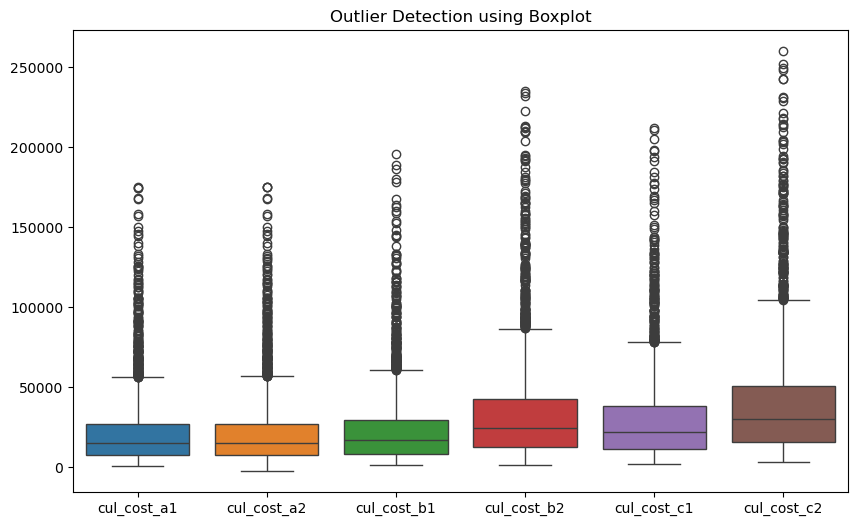

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[cost_cols])
plt.title("Outlier Detection using Boxplot")
plt.show()

In [24]:
# Example: mark rows with any outlier (IQR method)
Q1 = df[cost_cols].quantile(0.25)
Q3 = df[cost_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_flag = ((df[cost_cols] < (Q1 - 1.5*IQR)) | 
                (df[cost_cols] > (Q3 + 1.5*IQR)))

df['Outlier_Flag'] = outlier_flag.any(axis=1)

df[['Outlier_Flag']].value_counts()

Outlier_Flag
False           3449
True             240
Name: count, dtype: int64

In [25]:
# Interpretation (for your report / hypothesis)
# If many outliers exist → Reject H₀
# If few/no outliers → Fail to reject H₀

In [26]:
# Count outliers per method
summary = pd.DataFrame({
    "IQR": [len(iqr_outliers[col].dropna()) for col in cost_cols],
    "Z-score": [len(z_outliers[col].dropna()) for col in cost_cols],
    "MAD": [len(mad_outliers[col].dropna()) for col in cost_cols]
}, index=cost_cols)

print(summary)

             IQR  Z-score  MAD
cul_cost_a1  199       80  168
cul_cost_a2  200       79  168
cul_cost_b1  192       77  164
cul_cost_b2  193       83  151
cul_cost_c1  158       80  131
cul_cost_c2  167       80  134


In [27]:
# IQR Outlier Detection (row-wise)

cost_cols = ['cul_cost_a1','cul_cost_a2','cul_cost_b1','cul_cost_b2','cul_cost_c1','cul_cost_c2']

outlier_rows_iqr = pd.DataFrame()

for col in cost_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    temp = df[(df[col] < lower) | (df[col] > upper)]
    temp['Outlier_Column'] = col
    
    outlier_rows_iqr = pd.concat([outlier_rows_iqr, temp])

# Remove duplicates (same row appearing multiple times)
outlier_rows_iqr = outlier_rows_iqr.drop_duplicates()

print("Total Outlier Rows (IQR):", len(outlier_rows_iqr))
outlier_rows_iqr.head()

Total Outlier Rows (IQR): 1109


C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\4269509543.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['Outlier_Column'] = col
C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\4269509543.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['Outlier_Column'] = col
C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\4269509543.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,opr_cost,fix_cost_owned_land_rental,fix_cost_leased_land_rent,fix_cost_land_rev_tax_cess,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance,Outlier_Flag,Outlier_Column
1019,1058,2007-08,2007,2008,Maharashtra,27,Sugarcane,401,Sugar,58761.13,...,63876.54,14791.35,0.00,213.33,853.93,4921.74,20780.35,NaN,True,cul_cost_a1
1332,1371,2009-10,2009,2010,West Bengal,19,Potato,701,Vegetable,57948.76,...,63179.98,15399.58,170.52,26.43,238.85,511.48,16346.86,NaN,True,cul_cost_a1
1490,1529,2010-11,2010,2011,Tamil Nadu,33,Sugarcane,401,Sugar,57487.82,...,65421.48,17159.07,93.14,144.25,676.19,5531.14,23603.79,NaN,True,cul_cost_a1
1638,1677,2011-12,2011,2012,Uttar Pradesh,9,Potato,701,Vegetable,57866.71,...,64338.78,15140.28,512.66,18.47,346.97,4230.06,20248.44,NaN,True,cul_cost_a1
1639,1678,2011-12,2011,2012,West Bengal,19,Potato,701,Vegetable,59647.33,...,67598.94,12198.59,8112.69,22.85,248.50,738.78,21321.41,NaN,True,cul_cost_a1


In [28]:
# Z-score outlier detection

from scipy import stats

outlier_rows_z = pd.DataFrame()

for col in cost_cols:
    z = np.abs(stats.zscore(df[col], nan_policy='omit'))
    
    temp = df[z > 3]
    temp['Outlier_Column'] = col
    
    outlier_rows_z = pd.concat([outlier_rows_z, temp])

outlier_rows_z = outlier_rows_z.drop_duplicates()

print("Total Outlier Rows (Z-score):", len(outlier_rows_z))
outlier_rows_z.head()

Total Outlier Rows (Z-score): 479


C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\529835948.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['Outlier_Column'] = col
C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\529835948.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['Outlier_Column'] = col
C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\529835948.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,opr_cost,fix_cost_owned_land_rental,fix_cost_leased_land_rent,fix_cost_land_rev_tax_cess,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance,Outlier_Flag,Outlier_Column
1951,1990,2013-14,2013,2014,Maharashtra,27,Sugarcane,401,Sugar,89168.95,...,101011.05,33530.55,0.00,198.65,1080.18,10906.27,45715.65,NaN,True,cul_cost_a1
1952,1991,2013-14,2013,2014,Tamil Nadu,33,Sugarcane,401,Sugar,90316.97,...,104454.64,22315.33,11.91,9.65,598.68,6450.39,29385.96,NaN,True,cul_cost_a1
2101,2140,2014-15,2014,2015,West Bengal,19,Potato,701,Vegetable,89382.02,...,101969.41,26740.10,3110.81,39.50,405.64,1679.14,31975.19,NaN,True,cul_cost_a1
2105,2144,2014-15,2014,2015,Maharashtra,27,Sugarcane,401,Sugar,100936.50,...,112826.90,43508.55,0.00,212.58,902.05,8512.32,53135.50,NaN,True,cul_cost_a1
2106,2145,2014-15,2014,2015,Tamil Nadu,33,Sugarcane,401,Sugar,105832.00,...,123142.05,26631.87,9.20,13.46,678.06,7125.16,34457.75,NaN,True,cul_cost_a1


In [29]:
# MAD outlier detection

outlier_rows_mad = pd.DataFrame()

for col in cost_cols:
    median = np.median(df[col])
    mad = np.median(np.abs(df[col] - median))
    
    modified_z = 0.6745 * (df[col] - median) / mad
    
    temp = df[np.abs(modified_z) > 3.5]
    temp['Outlier_Column'] = col
    
    outlier_rows_mad = pd.concat([outlier_rows_mad, temp])

outlier_rows_mad = outlier_rows_mad.drop_duplicates()

print("Total Outlier Rows (MAD):", len(outlier_rows_mad))
outlier_rows_mad.head()

Total Outlier Rows (MAD): 916


C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\130799925.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['Outlier_Column'] = col
C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\130799925.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['Outlier_Column'] = col
C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\130799925.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,opr_cost,fix_cost_owned_land_rental,fix_cost_leased_land_rent,fix_cost_land_rev_tax_cess,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance,Outlier_Flag,Outlier_Column
1643,1682,2011-12,2011,2012,Maharashtra,27,Sugarcane,401,Sugar,64371.46,...,72976.01,36701.20,0.00,193.08,1052.53,16381.78,54328.59,NaN,True,cul_cost_a1
1644,1683,2011-12,2011,2012,Tamil Nadu,33,Sugarcane,401,Sugar,60807.85,...,71680.69,18791.79,77.57,114.73,554.00,6117.08,25655.17,NaN,True,cul_cost_a1
1794,1833,2012-13,2012,2013,Andhra Pradesh,28,Sugarcane,401,Sugar,66378.86,...,73797.22,48243.10,2698.82,0.28,200.54,2379.04,53521.78,NaN,True,cul_cost_a1
1797,1836,2012-13,2012,2013,Maharashtra,27,Sugarcane,401,Sugar,75585.59,...,85900.95,31168.93,0.00,219.03,994.99,10712.70,43095.65,NaN,True,cul_cost_a1
1798,1837,2012-13,2012,2013,Tamil Nadu,33,Sugarcane,401,Sugar,75408.77,...,88194.60,18277.42,748.70,12.30,628.01,5197.57,24864.00,NaN,True,cul_cost_a1


In [30]:
# Get common outliers
common_outliers = pd.merge(outlier_rows_iqr, outlier_rows_z, how='inner')
common_outliers = pd.merge(common_outliers, outlier_rows_mad, how='inner')

print("Common Outliers (All Methods):", len(common_outliers))
common_outliers.head()

Common Outliers (All Methods): 479


,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,opr_cost,fix_cost_owned_land_rental,fix_cost_leased_land_rent,fix_cost_land_rev_tax_cess,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance,Outlier_Flag,Outlier_Column
0,1990,2013-14,2013,2014,Maharashtra,27,Sugarcane,401,Sugar,89168.95,...,101011.05,33530.55,0.00,198.65,1080.18,10906.27,45715.65,NaN,True,cul_cost_a1
1,1991,2013-14,2013,2014,Tamil Nadu,33,Sugarcane,401,Sugar,90316.97,...,104454.64,22315.33,11.91,9.65,598.68,6450.39,29385.96,NaN,True,cul_cost_a1
2,2140,2014-15,2014,2015,West Bengal,19,Potato,701,Vegetable,89382.02,...,101969.41,26740.10,3110.81,39.50,405.64,1679.14,31975.19,NaN,True,cul_cost_a1
3,2144,2014-15,2014,2015,Maharashtra,27,Sugarcane,401,Sugar,100936.50,...,112826.90,43508.55,0.00,212.58,902.05,8512.32,53135.50,NaN,True,cul_cost_a1
4,2145,2014-15,2014,2015,Tamil Nadu,33,Sugarcane,401,Sugar,105832.00,...,123142.05,26631.87,9.20,13.46,678.06,7125.16,34457.75,NaN,True,cul_cost_a1


In [31]:
outlier_rows_iqr.to_csv("iqr_outliers.csv", index=False)
outlier_rows_z.to_csv("zscore_outliers.csv", index=False)
outlier_rows_mad.to_csv("mad_outliers.csv", index=False)

In [32]:
df.columns

Index(['id', 'year', 'start_year', 'end_year', 'state_name', 'state_code',
       'crop_name', 'crop_code', 'crop_type', 'cul_cost_a1', 'cul_cost_a2',
       'cul_cost_b1', 'cul_cost_b2', 'cul_cost_c1', 'cul_cost_c2',
       'cul_cost_c2rev', 'cul_cost_a2fl', 'prod_cost_a1', 'prod_cost_a2',
       'prod_cost_b1', 'prod_cost_b2', 'prod_cost_c1', 'prod_cost_c2',
       'prod_cost_c2rev', 'prod_cost_c3', 'prod_cost_a2fl',
       'main_product_value', 'by_product_value', 'mat_lab_input_seed',
       'mat_lab_input_fertilizer', 'mat_lab_input_manure',
       'mat_lab_input_hmn_lab', 'mat_lab_input_ani_lab', 'seed_rate_per_unit',
       'fert_rate_per_unit', 'manure_rate_per_unit', 'hmn_lab_rate_per_unit',
       'ani_lab_rate_per_unit', 'implicit_rate', 'num_holdings_sample',
       'num_tehsils_sample', 'derived_yield', 'hmn_lab_hrs_family',
       'hmn_lab_hrs_attached', 'hmn_lab_hrs_casual', 'opr_cost_hmn_lab_family',
       'opr_cost_hmn_lab_attached', 'opr_cost_hmn_lab_casual',
       

In [33]:
# Common outliers

top_crops = common_outliers['crop_name'].value_counts().reset_index()
top_crops.columns = ['Crop_name', 'Outlier_Count']

top_crops.head(10)

,Crop_name,Outlier_Count
0,Sugarcane,224
1,Potato,132
2,Onion,119
3,Cotton,3
4,Groundnut,1


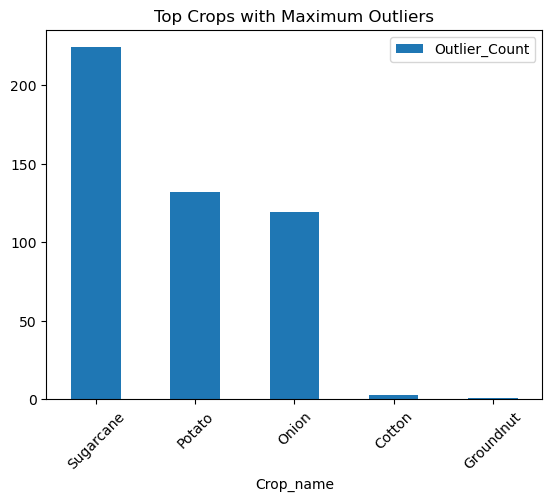

In [34]:
import matplotlib.pyplot as plt

top_crops.head(10).plot(kind='bar', x='Crop_name', y='Outlier_Count')
plt.title("Top Crops with Maximum Outliers")
plt.xticks(rotation=45)
plt.show()

## 2nd Objective
### - Component-wise Outlier Analysis
### Detect outliers in specific cost components such as labor (human/animal/machine), seeds, fertilizers, manure, irrigation, and crop insurance.

In [35]:
component_cols = [
    'opr_cost_hmn_lab_family',
    'opr_cost_hmn_lab_attached',
    'opr_cost_hmn_lab_casual',
    'opr_cost_ani_lab_hired',
    'opr_cost_ani_lab_owned',
    'opr_cost_mch_lab_hired',
    'opr_cost_mch_lab_owned',
    'opr_cost_seed',
    'opr_cost_fertilizer',
    'opr_cost_manure',
    'opr_cost_irrigation_chrg',
    'opr_cost_crop_insurance'
]

In [36]:
# IQR Method
def outliers_iqr(data):
    outlier_dict = {}
    
    for col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = data[(data[col] < lower) | (data[col] > upper)]
        
        outlier_dict[col] = outliers
        print(f"{col}: {len(outliers)} outliers")
        
    return outlier_dict

iqr_out = outliers_iqr(df[component_cols])

opr_cost_hmn_lab_family: 216 outliers
opr_cost_hmn_lab_attached: 466 outliers
opr_cost_hmn_lab_casual: 259 outliers
opr_cost_ani_lab_hired: 270 outliers
opr_cost_ani_lab_owned: 248 outliers
opr_cost_mch_lab_hired: 135 outliers
opr_cost_mch_lab_owned: 417 outliers
opr_cost_seed: 346 outliers
opr_cost_fertilizer: 215 outliers
opr_cost_manure: 364 outliers
opr_cost_irrigation_chrg: 243 outliers
opr_cost_crop_insurance: 168 outliers


In [58]:
for col in component_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    print(f"{col}")
    print(f"Lower Limit: {lower}")
    print(f"Upper Limit: {upper}")
    print("-"*30)

opr_cost_hmn_lab_family
Lower Limit: -6510.08
Upper Limit: 17089.92
------------------------------
opr_cost_hmn_lab_attached
Lower Limit: -274.325
Upper Limit: 459.315
------------------------------
opr_cost_hmn_lab_casual
Lower Limit: -8167.999999999999
Upper Limit: 17451.44
------------------------------
opr_cost_ani_lab_hired
Lower Limit: -636.125
Upper Limit: 1088.635
------------------------------
opr_cost_ani_lab_owned
Lower Limit: -1886.1950000000002
Upper Limit: 3583.925
------------------------------
opr_cost_mch_lab_hired
Lower Limit: -4259.344999999999
Upper Limit: 9172.454999999998
------------------------------
opr_cost_mch_lab_owned
Lower Limit: -762.6499999999999
Upper Limit: 1320.9499999999998
------------------------------
opr_cost_seed
Lower Limit: -3021.3349999999996
Upper Limit: 6864.465
------------------------------
opr_cost_fertilizer
Lower Limit: -3014.62
Upper Limit: 6765.86
------------------------------
opr_cost_manure
Lower Limit: -1094.57
Upper Limit: 1832.

In [37]:
# Z-score Method
def outliers_zscore(data, threshold=3):
    outlier_dict = {}
    
    for col in data.columns:
        z = np.abs(stats.zscore(data[col], nan_policy='omit'))
        outliers = data[z > threshold]
        
        outlier_dict[col] = outliers
        print(f"{col}: {len(outliers)} outliers")
        
    return outlier_dict

z_out = outliers_zscore(df[component_cols])

opr_cost_hmn_lab_family: 70 outliers
opr_cost_hmn_lab_attached: 81 outliers
opr_cost_hmn_lab_casual: 80 outliers
opr_cost_ani_lab_hired: 58 outliers
opr_cost_ani_lab_owned: 68 outliers
opr_cost_mch_lab_hired: 51 outliers
opr_cost_mch_lab_owned: 84 outliers
opr_cost_seed: 77 outliers
opr_cost_fertilizer: 62 outliers
opr_cost_manure: 76 outliers
opr_cost_irrigation_chrg: 77 outliers
opr_cost_crop_insurance: 12 outliers


In [38]:
# MAD Method
def outliers_mad(data, threshold=3.5):
    outlier_dict = {}
    
    for col in data.columns:
        median = np.median(data[col])
        mad = np.median(np.abs(data[col] - median))
        
        modified_z = 0.6745 * (data[col] - median) / mad
        outliers = data[np.abs(modified_z) > threshold]
        
        outlier_dict[col] = outliers
        print(f"{col}: {len(outliers)} outliers")
        
    return outlier_dict

mad_out = outliers_mad(df[component_cols])

opr_cost_hmn_lab_family: 183 outliers
opr_cost_hmn_lab_attached: 765 outliers
opr_cost_hmn_lab_casual: 300 outliers
opr_cost_ani_lab_hired: 479 outliers
opr_cost_ani_lab_owned: 267 outliers
opr_cost_mch_lab_hired: 136 outliers
opr_cost_mch_lab_owned: 745 outliers
opr_cost_seed: 352 outliers
opr_cost_fertilizer: 193 outliers
opr_cost_manure: 577 outliers
opr_cost_irrigation_chrg: 555 outliers
opr_cost_crop_insurance: 0 outliers


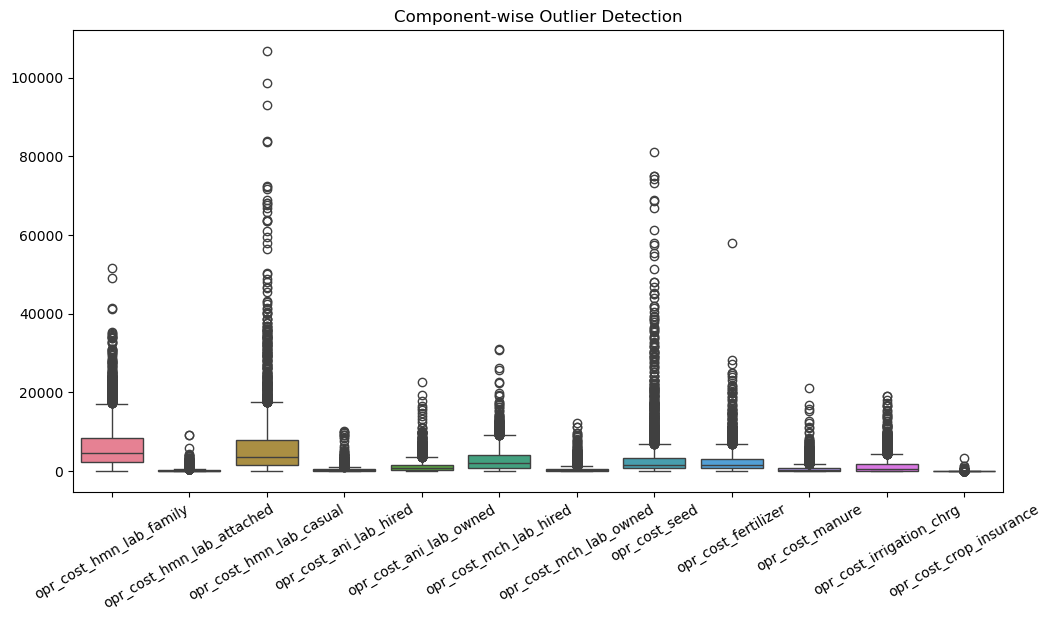

In [39]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[component_cols])
plt.xticks(rotation=30)
plt.title("Component-wise Outlier Detection")
plt.show()

In [40]:
outlier_rows = pd.DataFrame()

for col in component_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    temp = df[(df[col] < lower) | (df[col] > upper)]
    temp['Outlier_Component'] = col
    
    outlier_rows = pd.concat([outlier_rows, temp])

outlier_rows = outlier_rows.drop_duplicates()

print("Total Outlier Rows:", len(outlier_rows))
outlier_rows.head()

Total Outlier Rows: 3347


C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\3349553026.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['Outlier_Component'] = col
C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\3349553026.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['Outlier_Component'] = col
C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\3349553026.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,opr_cost,fix_cost_owned_land_rental,fix_cost_leased_land_rent,fix_cost_land_rev_tax_cess,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance,Outlier_Flag,Outlier_Component
1824,1863,2013-14,2013,2014,Rajasthan,8,Cotton,1101,Fiber Crops,17495.13,...,35570.57,15796.61,0.0,8.07,242.53,2678.47,18725.68,NaN,False,opr_cost_hmn_lab_family
1825,1864,2013-14,2013,2014,Tamil Nadu,33,Cotton,1101,Fiber Crops,30058.21,...,47392.59,9928.63,0.0,11.15,477.02,3509.51,13926.31,NaN,False,opr_cost_hmn_lab_family
1876,1915,2013-14,2013,2014,Uttarakhand,5,Ragi,105,Cereals,19080.60,...,38069.70,5934.93,0.0,0.00,734.74,269.40,6939.07,NaN,False,opr_cost_hmn_lab_family
1938,1977,2013-14,2013,2014,Odisha,21,Jute,1102,Fiber Crops,21408.47,...,38720.74,9156.46,0.0,16.56,591.84,2037.09,11801.95,NaN,False,opr_cost_hmn_lab_family
1972,2011,2014-15,2014,2015,Haryana,6,Cotton,1101,Fiber Crops,23237.65,...,43367.47,20205.15,0.0,0.00,431.12,3125.81,23762.08,NaN,False,opr_cost_hmn_lab_family


In [41]:
summary = pd.DataFrame({
    "IQR": [len(iqr_out[col]) for col in component_cols],
    "Z-score": [len(z_out[col]) for col in component_cols],
    "MAD": [len(mad_out[col]) for col in component_cols]
}, index=component_cols)

print(summary)

                           IQR  Z-score  MAD
opr_cost_hmn_lab_family    216       70  183
opr_cost_hmn_lab_attached  466       81  765
opr_cost_hmn_lab_casual    259       80  300
opr_cost_ani_lab_hired     270       58  479
opr_cost_ani_lab_owned     248       68  267
opr_cost_mch_lab_hired     135       51  136
opr_cost_mch_lab_owned     417       84  745
opr_cost_seed              346       77  352
opr_cost_fertilizer        215       62  193
opr_cost_manure            364       76  577
opr_cost_irrigation_chrg   243       77  555
opr_cost_crop_insurance    168       12    0


In [42]:
print("If outliers are high → Reject H0")

If outliers are high → Reject H0


In [43]:
# Combine 

df['total_human_labour'] = (
    df['opr_cost_hmn_lab_family'] +
    df['opr_cost_hmn_lab_attached'] +
    df['opr_cost_hmn_lab_casual']
)

df['total_animal_labour'] = (
    df['opr_cost_ani_lab_hired'] +
    df['opr_cost_ani_lab_owned']
)

df['total_machine_labour'] = (
    df['opr_cost_mch_lab_hired'] +
    df['opr_cost_mch_lab_owned']
)

In [44]:
component_cols = [
    'total_human_labour',
    'total_animal_labour',
    'total_machine_labour',
    'opr_cost_seed',
    'opr_cost_fertilizer',
    'opr_cost_manure',
    'opr_cost_irrigation_chrg',
    'opr_cost_crop_insurance'
]

In [45]:
df[component_cols].info()
df[component_cols].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3689 entries, 0 to 3688
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   total_human_labour        3689 non-null   float64
 1   total_animal_labour       3689 non-null   float64
 2   total_machine_labour      3689 non-null   float64
 3   opr_cost_seed             3689 non-null   float64
 4   opr_cost_fertilizer       3689 non-null   float64
 5   opr_cost_manure           3689 non-null   float64
 6   opr_cost_irrigation_chrg  3689 non-null   float64
 7   opr_cost_crop_insurance   965 non-null    float64
dtypes: float64(8)
memory usage: 230.7 KB


,total_human_labour,total_animal_labour,total_machine_labour,opr_cost_seed,opr_cost_fertilizer,opr_cost_manure,opr_cost_irrigation_chrg,opr_cost_crop_insurance
count,3689.000000,3689.000000,3689.000000,3689.000000,3689.000000,3689.000000,3689.000000,965.000000
mean,12814.168078,1525.565459,3370.448379,3300.791491,2370.790146,655.659371,1253.400266,27.650052
std,12412.956566,1909.408172,3338.561342,6485.415774,2944.215460,1273.697266,1988.978690,143.430232
min,582.950000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4449.810000,291.410000,926.050000,685.840000,653.060000,3.070000,44.780000,0.000000
50%,9198.940000,910.940000,2272.140000,1502.870000,1560.140000,194.290000,431.840000,0.000000
75%,16664.600000,2044.480000,4879.520000,3157.290000,3098.180000,734.830000,1740.980000,0.000000
max,122052.560000,22574.470000,33427.090000,81075.720000,58035.000000,21112.060000,19100.720000,3366.470000


In [47]:
component_cols = [
    'opr_cost_hmn_lab_family',
    'opr_cost_hmn_lab_attached',
    'opr_cost_hmn_lab_casual',
    'opr_cost_ani_lab_hired',
    'opr_cost_ani_lab_owned',
    'opr_cost_mch_lab_hired',
    'opr_cost_mch_lab_owned',
    'opr_cost_seed',
    'opr_cost_fertilizer',
    'opr_cost_manure',
    'opr_cost_irrigation_chrg',
    'opr_cost_crop_insurance'
]

outlier_details = []

for col in component_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    temp = df[(df[col] < lower) | (df[col] > upper)].copy()
    
    temp['Outlier_Component'] = col
    temp['Outlier_Value'] = temp[col]
    
    outlier_details.append(temp)

# Combine all
outlier_df = pd.concat(outlier_details).drop_duplicates()

print("Total Outlier Rows:", len(outlier_df))
outlier_df.head()

Total Outlier Rows: 3347


,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance,Outlier_Flag,total_human_labour,total_animal_labour,total_machine_labour,Outlier_Component,Outlier_Value
1824,1863,2013-14,2013,2014,Rajasthan,8,Cotton,1101,Fiber Crops,17495.13,...,242.53,2678.47,18725.68,NaN,False,22199.22,518.17,2072.74,opr_cost_hmn_lab_family,18326.04
1825,1864,2013-14,2013,2014,Tamil Nadu,33,Cotton,1101,Fiber Crops,30058.21,...,477.02,3509.51,13926.31,NaN,False,30403.40,487.66,3364.64,opr_cost_hmn_lab_family,17822.55
1876,1915,2013-14,2013,2014,Uttarakhand,5,Ragi,105,Cereals,19080.60,...,734.74,269.40,6939.07,NaN,False,25487.63,9226.51,0.00,opr_cost_hmn_lab_family,19723.83
1938,1977,2013-14,2013,2014,Odisha,21,Jute,1102,Fiber Crops,21408.47,...,591.84,2037.09,11801.95,NaN,False,31384.43,1973.69,2127.87,opr_cost_hmn_lab_family,17920.67
1972,2011,2014-15,2014,2015,Haryana,6,Cotton,1101,Fiber Crops,23237.65,...,431.12,3125.81,23762.08,NaN,False,25786.12,1157.23,3381.86,opr_cost_hmn_lab_family,20560.94


In [51]:
# Only Important Columns
# Suppose you have crop column
outlier_df[['crop_name', 'Outlier_Component', 'Outlier_Value']].head(10)

,crop_name,Outlier_Component,Outlier_Value
1824,Cotton,opr_cost_hmn_lab_family,18326.04
1825,Cotton,opr_cost_hmn_lab_family,17822.55
1876,Ragi,opr_cost_hmn_lab_family,19723.83
1938,Jute,opr_cost_hmn_lab_family,17920.67
1972,Cotton,opr_cost_hmn_lab_family,20560.94
1978,Cotton,opr_cost_hmn_lab_family,18096.68
1979,Cotton,opr_cost_hmn_lab_family,24044.62
2030,Ragi,opr_cost_hmn_lab_family,17432.15
2091,Jute,opr_cost_hmn_lab_family,20592.96
2092,Jute,opr_cost_hmn_lab_family,22296.69


In [52]:
# Top Components with Most Outliers
outlier_df['Outlier_Component'].value_counts()

Outlier_Component
opr_cost_hmn_lab_attached    466
opr_cost_mch_lab_owned       417
opr_cost_manure              364
opr_cost_seed                346
opr_cost_ani_lab_hired       270
opr_cost_hmn_lab_casual      259
opr_cost_ani_lab_owned       248
opr_cost_irrigation_chrg     243
opr_cost_hmn_lab_family      216
opr_cost_fertilizer          215
opr_cost_crop_insurance      168
opr_cost_mch_lab_hired       135
Name: count, dtype: int64

In [53]:
outlier_df['Outlier_Count'] = outlier_df.groupby(outlier_df.index)['Outlier_Component'].transform('count')

# Highly affected rows
outlier_df.sort_values(by='Outlier_Count', ascending=False).head(10)

,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance,Outlier_Flag,total_human_labour,total_animal_labour,total_machine_labour,Outlier_Component,Outlier_Value,Outlier_Count
3683,771,2023-24,2023,2024,Maharashtra,27,Sugarcane,401,Sugar,150028.52,...,17394.24,64151.85,3.21,True,75676.86,5882.81,32899.07,opr_cost_irrigation_chrg,19100.72,11
3485,573,2022-23,2022,2023,Maharashtra,27,Sugarcane,401,Sugar,167533.54,...,18718.12,68425.05,0.36,True,80703.86,4278.02,33427.09,opr_cost_seed,12750.90,11
3683,771,2023-24,2023,2024,Maharashtra,27,Sugarcane,401,Sugar,150028.52,...,17394.24,64151.85,3.21,True,75676.86,5882.81,32899.07,opr_cost_fertilizer,20211.20,11
3485,573,2022-23,2022,2023,Maharashtra,27,Sugarcane,401,Sugar,167533.54,...,18718.12,68425.05,0.36,True,80703.86,4278.02,33427.09,opr_cost_fertilizer,23759.59,11
3485,573,2022-23,2022,2023,Maharashtra,27,Sugarcane,401,Sugar,167533.54,...,18718.12,68425.05,0.36,True,80703.86,4278.02,33427.09,opr_cost_irrigation_chrg,19083.41,11
3683,771,2023-24,2023,2024,Maharashtra,27,Sugarcane,401,Sugar,150028.52,...,17394.24,64151.85,3.21,True,75676.86,5882.81,32899.07,opr_cost_seed,9864.80,11
3683,771,2023-24,2023,2024,Maharashtra,27,Sugarcane,401,Sugar,150028.52,...,17394.24,64151.85,3.21,True,75676.86,5882.81,32899.07,opr_cost_mch_lab_hired,30769.54,11
3485,573,2022-23,2022,2023,Maharashtra,27,Sugarcane,401,Sugar,167533.54,...,18718.12,68425.05,0.36,True,80703.86,4278.02,33427.09,opr_cost_mch_lab_hired,30953.41,11
3485,573,2022-23,2022,2023,Maharashtra,27,Sugarcane,401,Sugar,167533.54,...,18718.12,68425.05,0.36,True,80703.86,4278.02,33427.09,opr_cost_ani_lab_hired,3005.58,11
3683,771,2023-24,2023,2024,Maharashtra,27,Sugarcane,401,Sugar,150028.52,...,17394.24,64151.85,3.21,True,75676.86,5882.81,32899.07,opr_cost_manure,3048.53,11


In [55]:
# Strong Outliers
strong_outliers = outlier_df[outlier_df['Outlier_Count'] >= 2]

print("Strong Outliers:", len(strong_outliers))
strong_outliers.head()

Strong Outliers: 2628


,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance,Outlier_Flag,total_human_labour,total_animal_labour,total_machine_labour,Outlier_Component,Outlier_Value,Outlier_Count
1876,1915,2013-14,2013,2014,Uttarakhand,5,Ragi,105,Cereals,19080.60,...,269.40,6939.07,NaN,False,25487.63,9226.51,0.00,opr_cost_hmn_lab_family,19723.83,3
1972,2011,2014-15,2014,2015,Haryana,6,Cotton,1101,Fiber Crops,23237.65,...,3125.81,23762.08,NaN,False,25786.12,1157.23,3381.86,opr_cost_hmn_lab_family,20560.94,2
1978,2017,2014-15,2014,2015,Rajasthan,8,Cotton,1101,Fiber Crops,21489.96,...,2518.60,18363.40,NaN,False,22862.33,623.03,2335.53,opr_cost_hmn_lab_family,18096.68,3
1979,2018,2014-15,2014,2015,Tamil Nadu,33,Cotton,1101,Fiber Crops,32200.74,...,3984.56,16971.71,NaN,False,36743.17,304.50,3966.28,opr_cost_hmn_lab_family,24044.62,2
2030,2069,2014-15,2014,2015,Uttarakhand,5,Ragi,105,Cereals,17156.65,...,313.47,5390.06,NaN,False,22428.65,8394.13,0.00,opr_cost_hmn_lab_family,17432.15,3


In [56]:
outlier_df.to_csv("component_outliers.csv", index=False)
strong_outliers.to_csv("strong_outliers.csv", index=False)

## 3rd Objective
### - Regional Comparison
#### Compare cost outliers across states/regions (state_code) to highlight structural inefficiencies and regional disparities in cultivation practices.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [76]:
cost_cols = [
    'cul_cost_a1', 'cul_cost_a2',
    'cul_cost_b1', 'cul_cost_b2',
    'cul_cost_c1', 'cul_cost_c2'
]

In [77]:
# Create Outlier Flag column (row-wise)

Q1 = df[cost_cols].quantile(0.25)
Q3 = df[cost_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_flag = ((df[cost_cols] < (Q1 - 1.5*IQR)) |
                (df[cost_cols] > (Q3 + 1.5*IQR)))

df['Outlier_Flag'] = outlier_flag.any(axis=1)

df[['state_code', 'Outlier_Flag']].head()

,state_code,Outlier_Flag
0,2,False
1,2,False
2,3,False
3,3,False
4,3,False


In [102]:
cost_cols = [
    'cul_cost_a1','cul_cost_a2',
    'cul_cost_b1','cul_cost_b2',
    'cul_cost_c1','cul_cost_c2'
]

range_df = pd.DataFrame(columns=['Variable','Lower_Limit','Upper_Limit'])

for col in cost_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    range_df = pd.concat([range_df, pd.DataFrame({
        'Variable':[col],
        'Lower_Limit':[lower],
        'Upper_Limit':[upper]
    })])

print(range_df)

      Variable  Lower_Limit  Upper_Limit
0  cul_cost_a1   -22057.390    56304.370
0  cul_cost_a2   -22303.900    56900.340
0  cul_cost_b1   -22936.085    60761.795
0  cul_cost_b2   -32250.645    87012.115
0  cul_cost_c1   -28537.855    78352.825
0  cul_cost_c2   -37863.085   104371.595


C:\Users\Trupti\AppData\Local\Temp\ipykernel_17884\2127217648.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  range_df = pd.concat([range_df, pd.DataFrame({


In [104]:
#Outlier Values with Range
for col in cost_cols:
    lower = range_df[range_df['Variable']==col]['Lower_Limit'].values[0]
    upper = range_df[range_df['Variable']==col]['Upper_Limit'].values[0]
    
    print(f"\n{col} Outliers:")
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(outliers[[col]].head())


cul_cost_a1 Outliers:
      cul_cost_a1
1019     58761.13
1332     57948.76
1490     57487.82
1638     57866.71
1639     59647.33

cul_cost_a2 Outliers:
      cul_cost_a2
1019     58761.13
1332     58119.29
1490     57580.96
1638     58379.38
1639     67760.02

cul_cost_b1 Outliers:
      cul_cost_b1
1019     63682.87
1489     62716.27
1490     63018.95
1638     62096.77
1643     80753.23

cul_cost_b2 Outliers:
      cul_cost_b2
1640     96315.88
1643    117454.40
1787     94186.05
1793     87124.09
1794    119699.80

cul_cost_c1 Outliers:
      cul_cost_c1
1643     90603.38
1644     78466.49
1797     97827.66
1798     94032.49
1947     78422.41

cul_cost_c2 Outliers:
      cul_cost_c2
1643     127304.6
1794     127319.0
1797     128996.6
1798     113058.6
1947     108621.3


In [78]:
# State-wise Outlier Count

state_outliers = df.groupby('state_code')['Outlier_Flag'].sum().reset_index()
state_outliers.columns = ['State', 'Outlier_Count']

state_outliers = state_outliers.sort_values(by='Outlier_Count', ascending=False)

state_outliers.head(5)

,State,Outlier_Count
14,27,41
15,28,29
18,33,28
13,24,23
8,19,19


In [79]:
# State-wise Total Observations
state_total = df.groupby('state_code').size().reset_index(name='Total')

# Rename for merging
state_total.columns = ['State', 'Total']

In [80]:
# Merge + Percentage Calculation

state_summary = pd.merge(state_outliers, state_total, on='State')

state_summary['Outlier_Percentage'] = (
    state_summary['Outlier_Count'] / state_summary['Total'] * 100
)

state_summary = state_summary.sort_values(by='Outlier_Percentage', ascending=False)

state_summary.head(10)

,State,Outlier_Count,Total,Outlier_Percentage
9,36,10,41,24.390244
14,32,5,32,15.625000
2,33,28,223,12.556054
4,19,19,156,12.179487
0,27,41,342,11.988304
7,3,12,108,11.111111
10,18,8,80,10.000000
1,28,29,291,9.965636
3,24,23,246,9.349593
8,6,10,162,6.172840


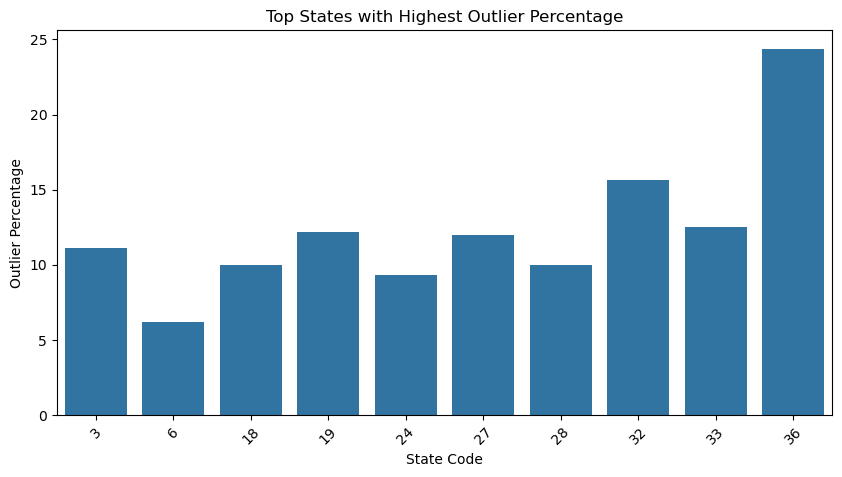

In [84]:
# Visualization

plt.figure(figsize=(10,5))

sns.barplot(data=state_summary.head(10),
            x='State', y='Outlier_Percentage')

plt.title("Top States with Highest Outlier Percentage")
plt.xticks(rotation=45)
plt.xlabel("State Code")
plt.ylabel("Outlier Percentage")

plt.show()

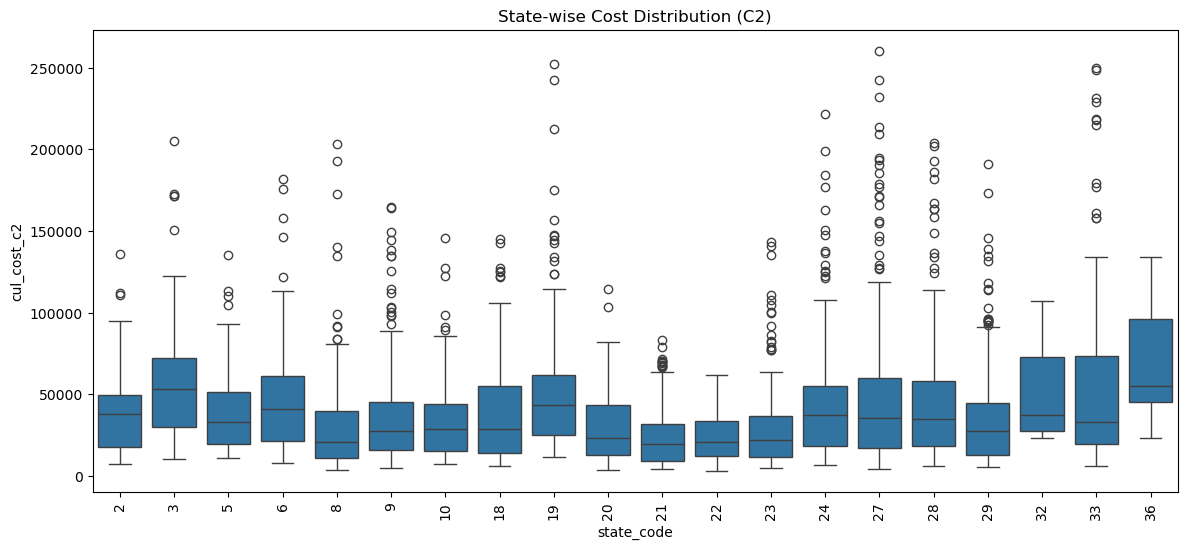

In [85]:
# Boxplot

plt.figure(figsize=(14,6))

sns.boxplot(x='state_code', y='cul_cost_c2', data=df)

plt.title("State-wise Cost Distribution (C2)")
plt.xticks(rotation=90)

plt.show()

In [86]:
# Top 5 Most Affected States

top_states = state_summary.head(5)

print("Top 5 States with Highest Outliers:\n")
print(top_states)

Top 5 States with Highest Outliers:

    State  Outlier_Count  Total  Outlier_Percentage
9      36             10     41           24.390244
14     32              5     32           15.625000
2      33             28    223           12.556054
4      19             19    156           12.179487
0      27             41    342           11.988304


In [87]:
state_summary.to_csv("state_wise_outliers.csv", index=False)

In [88]:
cost_cols = [
    'cul_cost_a1','cul_cost_a2',
    'cul_cost_b1','cul_cost_b2',
    'cul_cost_c1','cul_cost_c2'
]

outlier_rows = pd.DataFrame()

for col in cost_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    temp = df[(df[col] < lower) | (df[col] > upper)].copy()
    
    temp['Outlier_Variable'] = col
    
    outlier_rows = pd.concat([outlier_rows, temp])

# Remove duplicate rows
outlier_rows = outlier_rows.drop_duplicates()

print("Total Outlier Rows:", len(outlier_rows))
outlier_rows.head()

Total Outlier Rows: 1109


,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,fix_cost_land_rev_tax_cess,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance,Outlier_Flag,total_human_labour,total_animal_labour,total_machine_labour,Outlier_Variable
1019,1058,2007-08,2007,2008,Maharashtra,27,Sugarcane,401,Sugar,58761.13,...,213.33,853.93,4921.74,20780.35,NaN,True,20207.19,3885.99,6926.39,cul_cost_a1
1332,1371,2009-10,2009,2010,West Bengal,19,Potato,701,Vegetable,57948.76,...,26.43,238.85,511.48,16346.86,NaN,True,14939.32,1251.76,2311.50,cul_cost_a1
1490,1529,2010-11,2010,2011,Tamil Nadu,33,Sugarcane,401,Sugar,57487.82,...,144.25,676.19,5531.14,23603.79,NaN,True,44882.02,301.28,1387.25,cul_cost_a1
1638,1677,2011-12,2011,2012,Uttar Pradesh,9,Potato,701,Vegetable,57866.71,...,18.47,346.97,4230.06,20248.44,NaN,True,10786.03,2290.93,2040.88,cul_cost_a1
1639,1678,2011-12,2011,2012,West Bengal,19,Potato,701,Vegetable,59647.33,...,22.85,248.50,738.78,21321.41,NaN,True,16056.31,1711.58,2584.96,cul_cost_a1


In [89]:
# State-wise Exact Outlier Observations
outlier_rows[['state_code','state_name', 'crop_name', 'Outlier_Variable']].head(10)

,state_code,state_name,crop_name,Outlier_Variable
1019,27,Maharashtra,Sugarcane,cul_cost_a1
1332,19,West Bengal,Potato,cul_cost_a1
1490,33,Tamil Nadu,Sugarcane,cul_cost_a1
1638,9,Uttar Pradesh,Potato,cul_cost_a1
1639,19,West Bengal,Potato,cul_cost_a1
1643,27,Maharashtra,Sugarcane,cul_cost_a1
1644,33,Tamil Nadu,Sugarcane,cul_cost_a1
1793,19,West Bengal,Potato,cul_cost_a1
1794,28,Andhra Pradesh,Sugarcane,cul_cost_a1
1797,27,Maharashtra,Sugarcane,cul_cost_a1


In [90]:
# State-wise Outlier Counts
state_outlier_counts = outlier_rows['state_code'].value_counts()

print(state_outlier_counts)

state_code
27    199
33    138
28    128
24    120
19     86
9      72
29     54
36     51
18     47
3      42
23     31
8      30
10     27
6      27
32     22
2      17
20     10
5       8
Name: count, dtype: int64


In [91]:
# Crop-wise Outliers
crop_outliers = outlier_rows['crop_name'].value_counts()

print(crop_outliers.head(10))

crop_name
Sugarcane      374
Potato         285
Onion          209
Cotton          79
Paddy           76
Groundnut       56
Maize           13
Jute             8
Tur (Arhar)      8
Jowar            1
Name: count, dtype: int64


In [92]:
# Top Outlier Observations
top_extreme = outlier_rows.sort_values(by='cul_cost_c2', ascending=False)

top_extreme[['state_code','crop_name','cul_cost_c2']].head(10)

,state_code,crop_name,cul_cost_c2
3485,27,Sugarcane,260222.51
3485,27,Sugarcane,260222.51
3485,27,Sugarcane,260222.51
3485,27,Sugarcane,260222.51
3485,27,Sugarcane,260222.51
3485,27,Sugarcane,260222.51
3678,19,Potato,252165.66
3678,19,Potato,252165.66
3678,19,Potato,252165.66
3678,19,Potato,252165.66


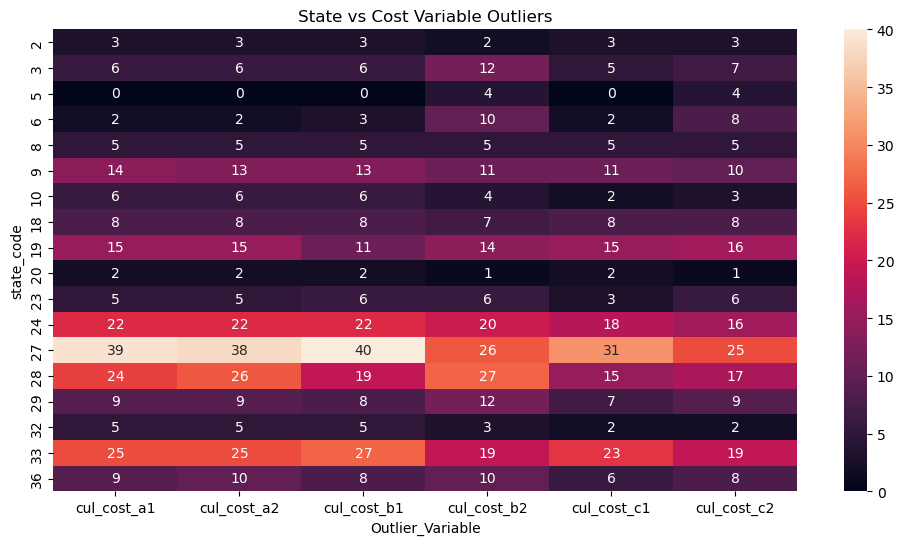

In [99]:
# heatmap
pivot = outlier_rows.pivot_table(index='state_code',
                                 columns='Outlier_Variable',
                                 aggfunc='size',
                                 fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt="d")

plt.title("State vs Cost Variable Outliers")
plt.show()

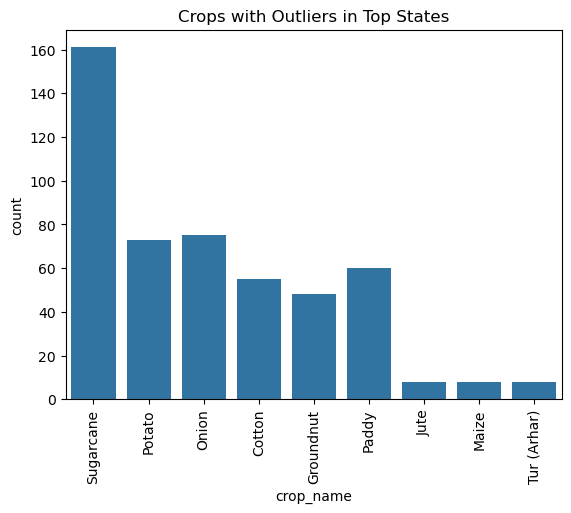

In [101]:
# Top Crops in Top States
top_states = state_summary.head(5)['State']

filtered = outlier_rows[outlier_rows['state_code'].isin(top_states)]

sns.countplot(data=filtered, x='crop_name')
plt.xticks(rotation=90)
plt.title("Crops with Outliers in Top States")
plt.show()

In [53]:
## The regional analysis indicates that cost outliers are not uniformly distributed across states. Certain states exhibit significantly higher outlier percentages, suggesting structural inefficiencies and regional disparities in cultivation practices. Hence, the null hypothesis (H₀) is rejected.

## 4th objective 
### - Derived Yield and Cost Linkage 
#### Relate detected cost outliers with derived_yield to check whether unusually high/low costs correspond to stressed crop performance.

In [54]:
cost_cols = [
    'cul_cost_a1', 'cul_cost_a2',
    'cul_cost_b1', 'cul_cost_b2',
    'cul_cost_c1', 'cul_cost_c2'
]

target = 'derived_yield'

In [56]:
# Outlier detection
Q1 = df[cost_cols].quantile(0.25)
Q3 = df[cost_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_flag = ((df[cost_cols] < (Q1 - 1.5 * IQR)) |
                (df[cost_cols] > (Q3 + 1.5 * IQR)))

df['Cost_Outlier'] = outlier_flag.any(axis=1)

In [105]:
cost_cols = [
    'cul_cost_a1', 'cul_cost_a2',
    'cul_cost_b1', 'cul_cost_b2',
    'cul_cost_c1', 'cul_cost_c2'
]

range_table = pd.DataFrame(columns=['Variable', 'Lower_Limit', 'Upper_Limit'])

for col in cost_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    range_table.loc[len(range_table)] = [col, lower, upper]

print(range_table)

      Variable  Lower_Limit  Upper_Limit
0  cul_cost_a1   -22057.390    56304.370
1  cul_cost_a2   -22303.900    56900.340
2  cul_cost_b1   -22936.085    60761.795
3  cul_cost_b2   -32250.645    87012.115
4  cul_cost_c1   -28537.855    78352.825
5  cul_cost_c2   -37863.085   104371.595


In [106]:
for col in cost_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    print(f"\n🔹 {col}")
    print("Lower Limit:", lower)
    print("Upper Limit:", upper)
    
    print("Low Outliers:")
    print(df[df[col] < lower][col].head())
    
    print("High Outliers:")
    print(df[df[col] > upper][col].head())


🔹 cul_cost_a1
Lower Limit: -22057.389999999996
Upper Limit: 56304.369999999995
Low Outliers:
Series([], Name: cul_cost_a1, dtype: float64)
High Outliers:
1019    58761.13
1332    57948.76
1490    57487.82
1638    57866.71
1639    59647.33
Name: cul_cost_a1, dtype: float64

🔹 cul_cost_a2
Lower Limit: -22303.900000000005
Upper Limit: 56900.340000000004
Low Outliers:
Series([], Name: cul_cost_a2, dtype: float64)
High Outliers:
1019    58761.13
1332    58119.29
1490    57580.96
1638    58379.38
1639    67760.02
Name: cul_cost_a2, dtype: float64

🔹 cul_cost_b1
Lower Limit: -22936.085
Upper Limit: 60761.795
Low Outliers:
Series([], Name: cul_cost_b1, dtype: float64)
High Outliers:
1019    63682.87
1489    62716.27
1490    63018.95
1638    62096.77
1643    80753.23
Name: cul_cost_b1, dtype: float64

🔹 cul_cost_b2
Lower Limit: -32250.645000000004
Upper Limit: 87012.115
Low Outliers:
Series([], Name: cul_cost_b2, dtype: float64)
High Outliers:
1640     96315.88
1643    117454.40
1787     94186

In [109]:
# Summary Count of High vs Low
for col in cost_cols:
    print(f"\n{col}")
    print(df[col + '_Outlier_Type'].value_counts())


cul_cost_a1
cul_cost_a1_Outlier_Type
Normal          3490
High Outlier     199
Name: count, dtype: int64

cul_cost_a2
cul_cost_a2_Outlier_Type
Normal          3489
High Outlier     200
Name: count, dtype: int64

cul_cost_b1
cul_cost_b1_Outlier_Type
Normal          3497
High Outlier     192
Name: count, dtype: int64

cul_cost_b2
cul_cost_b2_Outlier_Type
Normal          3496
High Outlier     193
Name: count, dtype: int64

cul_cost_c1
cul_cost_c1_Outlier_Type
Normal          3531
High Outlier     158
Name: count, dtype: int64

cul_cost_c2
cul_cost_c2_Outlier_Type
Normal          3522
High Outlier     167
Name: count, dtype: int64


In [57]:
# Compare Yield (Outlier vs Normal)
yield_comparison = df.groupby('Cost_Outlier')[target].describe()

print(yield_comparison)

               count        mean         std   min    25%      50%      75%  \
Cost_Outlier                                                                  
False         3449.0   39.241241  117.000786  0.83   7.66   13.170   26.480   
True           240.0  347.879250  342.943477  9.76  56.39  213.465  655.655   

                  max  
Cost_Outlier           
False         1185.73  
True          1135.38  


In [58]:
# Mean Yield Comparison
mean_yield = df.groupby('Cost_Outlier')[target].mean().reset_index()

mean_yield.columns = ['Cost_Outlier', 'Mean_Yield']

print(mean_yield)

   Cost_Outlier  Mean_Yield
0         False   39.241241
1          True  347.879250


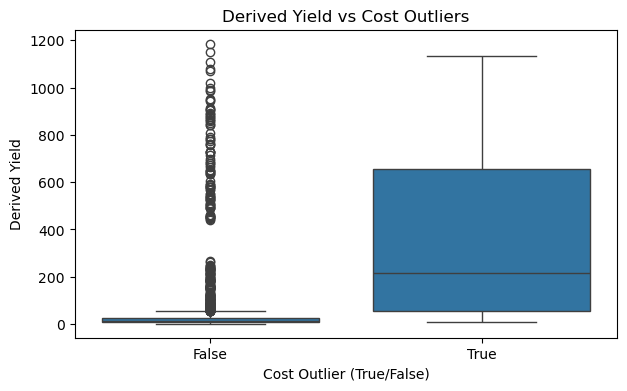

In [60]:
# Visualization (Boxplot)
plt.figure(figsize=(7,4))

sns.boxplot(x='Cost_Outlier', y=target, data=df)

plt.title("Derived Yield vs Cost Outliers")
plt.xlabel("Cost Outlier (True/False)")
plt.ylabel("Derived Yield")

plt.show()

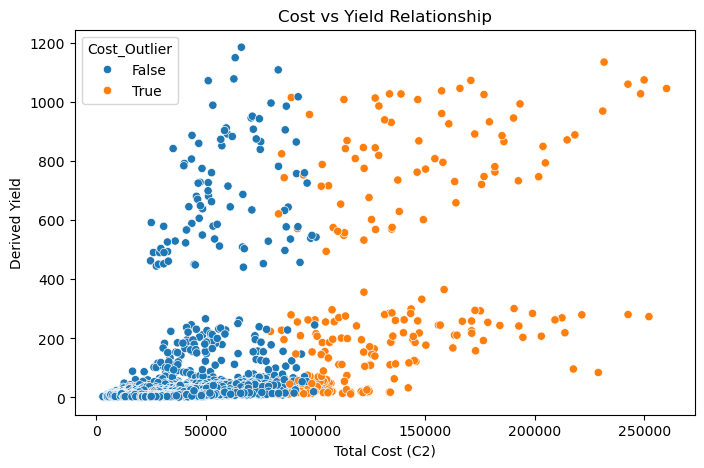

In [61]:
# Scatter Plot
plt.figure(figsize=(8,5))

sns.scatterplot(x='cul_cost_c2', y=target,
                hue='Cost_Outlier', data=df)

plt.title("Cost vs Yield Relationship")
plt.xlabel("Total Cost (C2)")
plt.ylabel("Derived Yield")

plt.show()

In [62]:
# Correlation Analysis
corr = df[cost_cols + [target]].corr()

print(corr[target].sort_values(ascending=False))

derived_yield    1.000000
cul_cost_b2      0.570327
cul_cost_c2      0.543203
cul_cost_b1      0.535005
cul_cost_a1      0.522225
cul_cost_a2      0.518410
cul_cost_c1      0.498480
Name: derived_yield, dtype: float64


In [63]:
# Statistical Test (T-test)
from scipy.stats import ttest_ind

outlier_yield = df[df['Cost_Outlier'] == True][target]
normal_yield = df[df['Cost_Outlier'] == False][target]

t_stat, p_value = ttest_ind(outlier_yield, normal_yield, nan_policy='omit')

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 32.34893538740881
P-value: 2.611817867387975e-202


In [64]:
# Hypothesis Decision
if p_value < 0.05:
    print("Reject H0 → Yield is linked to cost anomalies")
else:
    print("Fail to Reject H0 → No strong linkage")

Reject H0 → Yield is linked to cost anomalies


In [110]:
cost_cols = [
    'cul_cost_a1', 'cul_cost_a2',
    'cul_cost_b1', 'cul_cost_b2',
    'cul_cost_c1', 'cul_cost_c2'
]

outlier_rows = pd.DataFrame()

for col in cost_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    temp = df[(df[col] < lower) | (df[col] > upper)].copy()
    temp['Outlier_Variable'] = col
    
    outlier_rows = pd.concat([outlier_rows, temp])

# Remove duplicates
outlier_rows = outlier_rows.drop_duplicates()

print("Total Outlier Rows:", len(outlier_rows))
outlier_rows.head()

Total Outlier Rows: 1109


,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,total_human_labour,total_animal_labour,total_machine_labour,cul_cost_a1_Outlier_Type,cul_cost_a2_Outlier_Type,cul_cost_b1_Outlier_Type,cul_cost_b2_Outlier_Type,cul_cost_c1_Outlier_Type,cul_cost_c2_Outlier_Type,Outlier_Variable
1019,1058,2007-08,2007,2008,Maharashtra,27,Sugarcane,401,Sugar,58761.13,...,20207.19,3885.99,6926.39,High Outlier,High Outlier,High Outlier,Normal,Normal,Normal,cul_cost_a1
1332,1371,2009-10,2009,2010,West Bengal,19,Potato,701,Vegetable,57948.76,...,14939.32,1251.76,2311.50,High Outlier,High Outlier,Normal,Normal,Normal,Normal,cul_cost_a1
1490,1529,2010-11,2010,2011,Tamil Nadu,33,Sugarcane,401,Sugar,57487.82,...,44882.02,301.28,1387.25,High Outlier,High Outlier,High Outlier,Normal,Normal,Normal,cul_cost_a1
1638,1677,2011-12,2011,2012,Uttar Pradesh,9,Potato,701,Vegetable,57866.71,...,10786.03,2290.93,2040.88,High Outlier,High Outlier,High Outlier,Normal,Normal,Normal,cul_cost_a1
1639,1678,2011-12,2011,2012,West Bengal,19,Potato,701,Vegetable,59647.33,...,16056.31,1711.58,2584.96,High Outlier,High Outlier,Normal,Normal,Normal,Normal,cul_cost_a1


In [111]:
outlier_rows[['crop_name', 'state_code',
              'cul_cost_c2', 'derived_yield',
              'Outlier_Variable']].head(10)

,crop_name,state_code,cul_cost_c2,derived_yield,Outlier_Variable
1019,Sugarcane,27,84656.89,824.89,cul_cost_a1
1332,Potato,19,79526.84,223.70,cul_cost_a1
1490,Sugarcane,33,89025.27,1015.45,cul_cost_a1
1638,Potato,9,84587.22,227.69,cul_cost_a1
1639,Potato,19,88920.35,279.68,cul_cost_a1
1643,Sugarcane,27,127304.60,1013.81,cul_cost_a1
1644,Sugarcane,33,97335.86,958.01,cul_cost_a1
1793,Potato,19,96665.14,262.66,cul_cost_a1
1794,Sugarcane,28,127319.00,845.21,cul_cost_a1
1797,Sugarcane,27,128996.60,986.81,cul_cost_a1


In [115]:
#High vs Low Outliers
def label_outliers(row, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    if row[col] < lower:
        return "Low Outlier"
    elif row[col] > upper:
        return "High Outlier"
    else:
        return "Normal"

# Apply for one important variable (C2)
df['Outlier_Type_C2'] = df.apply(lambda row: label_outliers(row, 'cul_cost_c2'), axis=1)

df[['crop_name', 'cul_cost_c2', 'derived_yield', 'Outlier_Type_C2']].head(10)

,crop_name,cul_cost_c2,derived_yield,Outlier_Type_C2
0,Maize,7488.85,11.28,Normal
1,Potato,31630.92,87.53,Normal
2,Paddy,19126.17,46.45,Normal
3,Wheat,19479.22,42.46,Normal
4,Sunflower,12518.62,16.02,Normal
5,Rapeseed & Mustard (Toria/Taramira),10208.48,8.31,Normal
6,Cotton,15459.22,4.56,Normal
7,Bajra,7899.59,12.92,Normal
8,Cotton,15700.30,7.42,Normal
9,Paddy,19559.69,35.86,Normal


In [114]:
# Only Outlier Observations
final_outliers = df[df['Outlier_Type_C2'] != "Normal"]

final_outliers[['crop_name', 'state_code',
                'cul_cost_c2', 'derived_yield',
                'Outlier_Type_C2']].head(10)

,crop_name,state_code,cul_cost_c2,derived_yield,Outlier_Type_C2
1643,Sugarcane,27,127304.6,1013.81,High Outlier
1794,Sugarcane,28,127319.0,845.21,High Outlier
1797,Sugarcane,27,128996.6,986.81,High Outlier
1798,Sugarcane,33,113058.6,1008.79,High Outlier
1947,Potato,19,108621.3,256.32,High Outlier
1948,Sugarcane,28,124488.9,676.78,High Outlier
1949,Sugarcane,6,111564.2,654.52,High Outlier
1951,Sugarcane,27,146726.7,1008.55,High Outlier
1952,Sugarcane,33,133840.6,1027.80,High Outlier
2097,Onion,27,118792.3,242.33,High Outlier


In [116]:
df.groupby('Outlier_Type_C2')['derived_yield'].mean()

Outlier_Type_C2
High Outlier    428.093413
Normal           41.834884
Name: derived_yield, dtype: float64

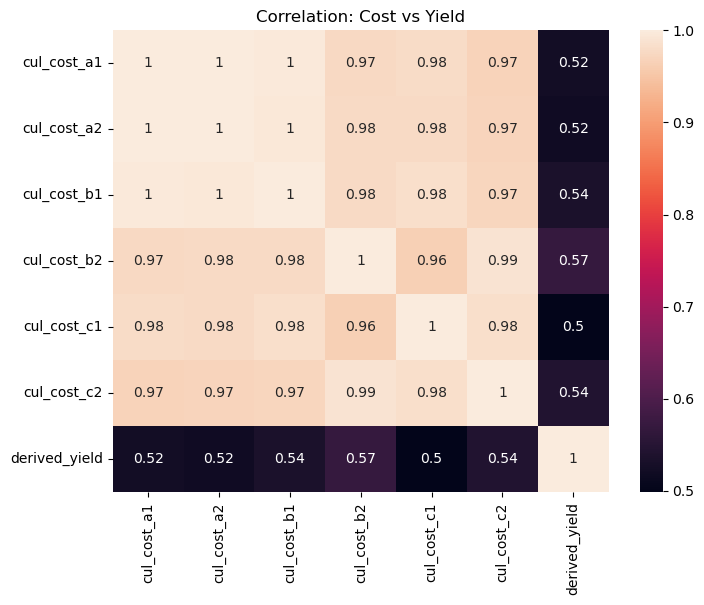

In [125]:
plt.figure(figsize=(8,6))

corr = df[['cul_cost_a1','cul_cost_a2','cul_cost_b1',
           'cul_cost_b2','cul_cost_c1','cul_cost_c2',
           'derived_yield']].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation: Cost vs Yield")

plt.show()

# 5th objective 
### - Economic Stress Identification 
#### Classify crops (crop_code) with significant cost outliers as potentially economically stressed, and interpret whether these stresses are structural (fixed costs), environmental (irrigation, manure), or policy-driven (interest, land rent, insurance).

In [166]:
# Load dataset
df = pd.read_csv("\\Users\\Trupti\\Downloads\\research paper msc 2\\cost-of-cultivation data final.csv")

# Preview data
df.head()

,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,opr_cost_misc,opr_cost_interest_on_wrk_cap,opr_cost,fix_cost_owned_land_rental,fix_cost_leased_land_rent,fix_cost_land_rev_tax_cess,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance
0,2951,2000-01,2000,2001,Himachal Pradesh,2,Maize,104,Cereals,1939.25,...,0.00,53.47,5222.99,1547.44,3.22,5.12,169.54,540.54,2265.86,NaN
1,2952,2000-01,2000,2001,Himachal Pradesh,2,Potato,701,Vegetable,15635.44,...,0.00,464.02,21614.97,8443.42,0.00,11.21,311.51,1249.81,10015.95,NaN
2,2953,2000-01,2000,2001,Punjab,3,Paddy,101,Cereals,9509.84,...,0.00,282.87,10729.06,6124.14,1089.99,0.00,175.08,1007.92,8397.13,NaN
3,2954,2000-01,2000,2001,Punjab,3,Wheat,106,Cereals,8474.80,...,34.09,250.23,9161.23,7445.70,1469.91,0.00,217.34,1185.04,10317.99,NaN
4,2955,2000-01,2000,2001,Punjab,3,Sunflower,1007,Oilseeds,4515.10,...,0.00,133.27,5199.96,2712.61,3971.23,0.00,117.14,517.68,7318.66,NaN


In [167]:
fix_cost_cols = [
    "fix_cost", "fix_cost_leased_land_rent",
    "fix_cost_interest_fix_cap", "opr_cost_irrigation_chrg",
    "opr_cost_manure", "opr_cost_interest_on_wrk_cap",
    "opr_cost_crop_insurance"
]

In [168]:
# Create Outlier Flag (IQR Method)
Q1 = df[fix_cost_cols].quantile(0.25)
Q3 = df[fix_cost_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_flag = ((df[fix_cost_cols] < (Q1 - 1.5 * IQR)) |
                (df[fix_cost_cols] > (Q3 + 1.5 * IQR)))

df['Cost_Outlier'] = outlier_flag.any(axis=1)

In [169]:
# Crop-wise Outlier Count
crop_outliers = df.groupby('crop_code')['Cost_Outlier'].sum().reset_index()

crop_outliers.columns = ['Crop', 'Outlier_Count']

In [170]:
# crop wise total observation
crop_total = df.groupby('crop_code').size().reset_index(name='Total')

crop_total.columns = ['Crop', 'Total']

In [171]:
# Merge + Percentage
crop_summary = pd.merge(crop_outliers, crop_total, on='Crop')

crop_summary['Outlier_Percentage'] = (
    crop_summary['Outlier_Count'] / crop_summary['Total'] * 100
)

crop_summary = crop_summary.sort_values(by='Outlier_Percentage', ascending=False)

crop_summary.head(10)

,Crop,Outlier_Count,Total,Outlier_Percentage
14,702,4,4,100.000000
12,401,127,169,75.147929
13,701,95,131,72.519084
15,708,57,87,65.517241
24,1101,111,230,48.260870
0,101,191,399,47.869674
5,106,127,284,44.718310
6,107,25,57,43.859649
17,1001,64,164,39.024390
3,104,98,263,37.262357


In [172]:
# Identify Economically Stressed Crops
# Threshold: >20% = stressed (can adjust)
crop_summary['Stress_Flag'] = crop_summary['Outlier_Percentage'] > 20

stressed_crops = crop_summary[crop_summary['Stress_Flag'] == True]

print("Economically Stressed Crops:\n")
print(stressed_crops.head(10))

Economically Stressed Crops:

    Crop  Outlier_Count  Total  Outlier_Percentage  Stress_Flag
14   702              4      4          100.000000         True
12   401            127    169           75.147929         True
13   701             95    131           72.519084         True
15   708             57     87           65.517241         True
24  1101            111    230           48.260870         True
0    101            191    399           47.869674         True
5    106            127    284           44.718310         True
6    107             25     57           43.859649         True
17  1001             64    164           39.024390         True
3    104             98    263           37.262357         True


In [173]:
# Classify Type of Stress
# Create stress categories
# Structural (Fixed Costs), Environmental, Policy-driven
df['Structural_Stress'] = (
    (df['fix_cost'] > df['fix_cost'].quantile(0.75))
)

df['Environmental_Stress'] = (
    (df['opr_cost_irrigation_chrg'] > df['opr_cost_irrigation_chrg'].quantile(0.75)) |
    (df['opr_cost_manure'] > df['opr_cost_manure'].quantile(0.75))
)

df['Policy_Stress'] = (
    (df['opr_cost_interest_on_wrk_cap'] > df['opr_cost_interest_on_wrk_cap'].quantile(0.75)) |
    (df['opr_cost_crop_insurance'] > df['opr_cost_crop_insurance'].quantile(0.75)) |
    (df['fix_cost_leased_land_rent'] > df['fix_cost_leased_land_rent'].quantile(0.75))
)

In [177]:
# Crop-wise Stress Type Summary
stress_summary = df.groupby('crop_code')[[
    'Structural_Stress',
    'Environmental_Stress',
    'Policy_Stress'
]].sum().reset_index()

stress_summary.columns = [
    'Crop',
    'Structural_Count',
    'Environmental_Count',
    'Policy_Count'
]

stress_summary.head(10)

,Crop,Structural_Count,Environmental_Count,Policy_Count
0,101,122,229,252
1,102,7,22,26
2,103,10,24,49
3,104,50,127,109
4,105,3,45,16
5,106,83,207,143
6,107,15,45,29
7,201,40,49,55
8,202,32,31,54
9,203,9,12,45


In [180]:
# Merge Stress + Outliers
final_summary = pd.merge(crop_summary, stress_summary, on='Crop')

final_summary.head(10)

,Crop,Outlier_Count,Total,Outlier_Percentage,Stress_Flag,Structural_Count,Environmental_Count,Policy_Count
0,702,4,4,100.000000,True,0,4,0
1,401,127,169,75.147929,True,150,154,157
2,701,95,131,72.519084,True,78,121,115
3,708,57,87,65.517241,True,61,65,64
4,1101,111,230,48.260870,True,116,114,133
5,101,191,399,47.869674,True,122,229,252
6,106,127,284,44.718310,True,83,207,143
7,107,25,57,43.859649,True,15,45,29
8,1001,64,164,39.024390,True,47,82,86
9,104,98,263,37.262357,True,50,127,109


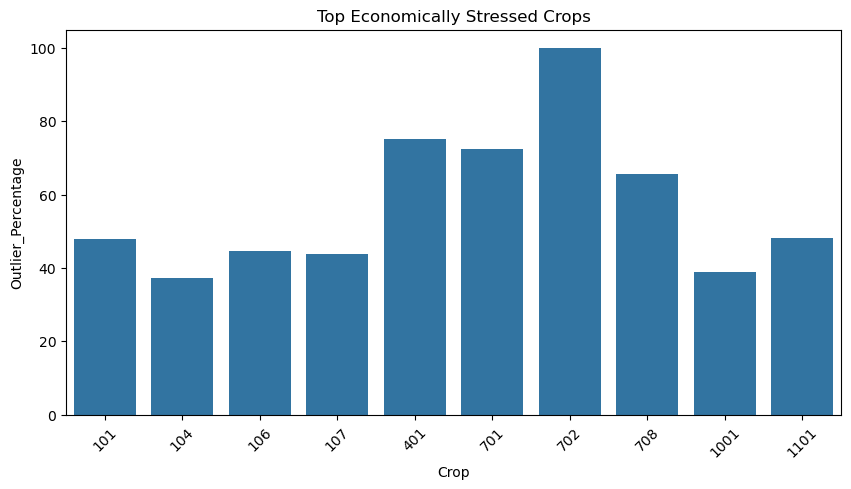

In [181]:
# Visualization (Top Stressed Crops)
plt.figure(figsize=(10,5))

sns.barplot(data=final_summary.head(10),
            x='Crop', y='Outlier_Percentage')

plt.title("Top Economically Stressed Crops")
plt.xticks(rotation=45)

plt.show()

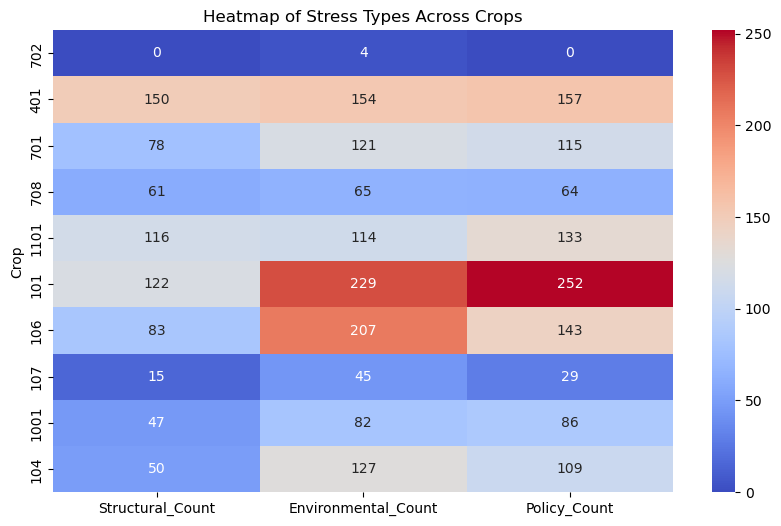

In [195]:
heat_data = final_summary.set_index('Crop')[[
    'Structural_Count',
    'Environmental_Count',
    'Policy_Count'
]].head(10)

plt.figure(figsize=(10,6))

sns.heatmap(heat_data, annot=True, fmt="g", cmap="coolwarm")

plt.title("Heatmap of Stress Types Across Crops")

plt.show()

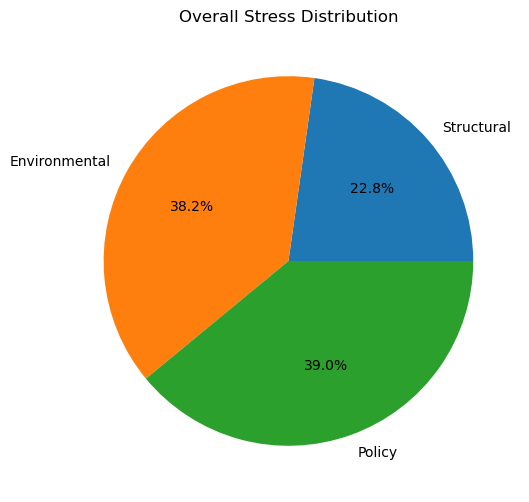

In [196]:
total_struct = final_summary['Structural_Count'].sum()
total_env = final_summary['Environmental_Count'].sum()
total_policy = final_summary['Policy_Count'].sum()

labels = ['Structural', 'Environmental', 'Policy']
values = [total_struct, total_env, total_policy]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Overall Stress Distribution")

plt.show()

In [188]:
final_summary.to_csv("crop_stress_analysis.csv", index=False)

# 6th Objective
### - Temporal Comparison
#### Examine cost outliers across years (if time dimension exists in your dataset or can be merged) to identify shifts due to external shocks like droughts or policy changes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("\\Users\\Trupti\\Downloads\\research paper msc 2\\cost-of-cultivation data final.csv")

df.head()

,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,opr_cost_misc,opr_cost_interest_on_wrk_cap,opr_cost,fix_cost_owned_land_rental,fix_cost_leased_land_rent,fix_cost_land_rev_tax_cess,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance
0,2951,2000-01,2000,2001,Himachal Pradesh,2,Maize,104,Cereals,1939.25,...,0.00,53.47,5222.99,1547.44,3.22,5.12,169.54,540.54,2265.86,NaN
1,2952,2000-01,2000,2001,Himachal Pradesh,2,Potato,701,Vegetable,15635.44,...,0.00,464.02,21614.97,8443.42,0.00,11.21,311.51,1249.81,10015.95,NaN
2,2953,2000-01,2000,2001,Punjab,3,Paddy,101,Cereals,9509.84,...,0.00,282.87,10729.06,6124.14,1089.99,0.00,175.08,1007.92,8397.13,NaN
3,2954,2000-01,2000,2001,Punjab,3,Wheat,106,Cereals,8474.80,...,34.09,250.23,9161.23,7445.70,1469.91,0.00,217.34,1185.04,10317.99,NaN
4,2955,2000-01,2000,2001,Punjab,3,Sunflower,1007,Oilseeds,4515.10,...,0.00,133.27,5199.96,2712.61,3971.23,0.00,117.14,517.68,7318.66,NaN


In [4]:
df['year'].unique()

array(['2000-01', '2001-02', '2002-03', '2003-04', '2004-05', '2005-06',
       '2006-07', '2007-08', '2008-09', '2009-10', '2010-11', '2011-12',
       '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18',
       '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24'],
      dtype=object)

In [5]:
cost_cols = [
    'cul_cost_a1', 'cul_cost_a2',
    'cul_cost_b1', 'cul_cost_b2',
    'cul_cost_c1', 'cul_cost_c2'
]

In [6]:
Q1 = df[cost_cols].quantile(0.25)
Q3 = df[cost_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_flag = ((df[cost_cols] < (Q1 - 1.5 * IQR)) |
                (df[cost_cols] > (Q3 + 1.5 * IQR)))

df['Cost_Outlier'] = outlier_flag.any(axis=1)

In [9]:
# Year-wise Outlier Count
year_outliers = df.groupby('year')['Cost_Outlier'].sum().reset_index()

year_outliers.columns = ['Year', 'Outlier_Count']

year_outliers

,Year,Outlier_Count
0,2000-01,0
1,2001-02,0
2,2002-03,0
3,2003-04,0
4,2004-05,0
5,2005-06,0
6,2006-07,0
7,2007-08,1
8,2008-09,0
9,2009-10,1


In [10]:
# Year-wise Total Observations
year_total = df.groupby('year').size().reset_index(name='Total')

year_total.columns = ['Year', 'Total']

In [12]:
# Merge + Percentage
year_summary = pd.merge(year_outliers, year_total, on='Year')

year_summary['Outlier_Percentage'] = (
    year_summary['Outlier_Count'] / year_summary['Total'] * 100
)

year_summary = year_summary.sort_values(by='Year')

year_summary

,Year,Outlier_Count,Total,Outlier_Percentage
0,2000-01,0,102,0.000000
1,2001-02,0,116,0.000000
2,2002-03,0,120,0.000000
3,2003-04,0,120,0.000000
4,2004-05,0,139,0.000000
5,2005-06,0,141,0.000000
6,2006-07,0,140,0.000000
7,2007-08,1,151,0.662252
8,2008-09,0,153,0.000000
9,2009-10,1,158,0.632911


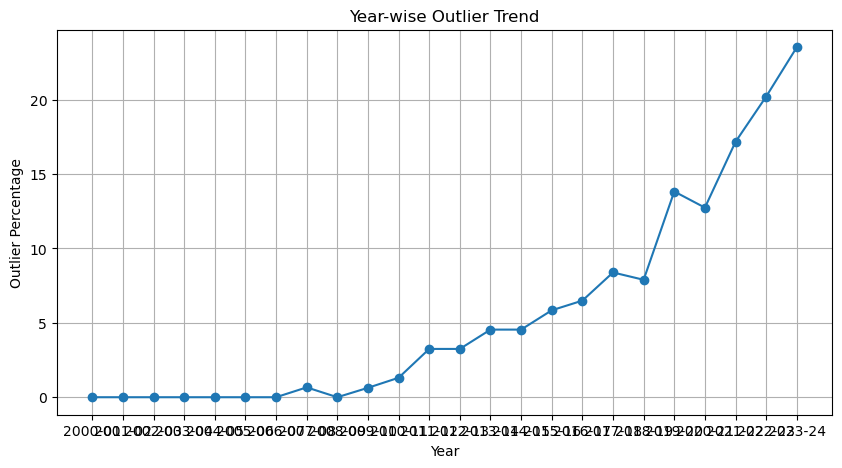

In [13]:
# Line Plot (Trend Over Time)
plt.figure(figsize=(10,5))

plt.plot(year_summary['Year'], year_summary['Outlier_Percentage'], marker='o')

plt.title("Year-wise Outlier Trend")
plt.xlabel("Year")
plt.ylabel("Outlier Percentage")

plt.grid()
plt.show()

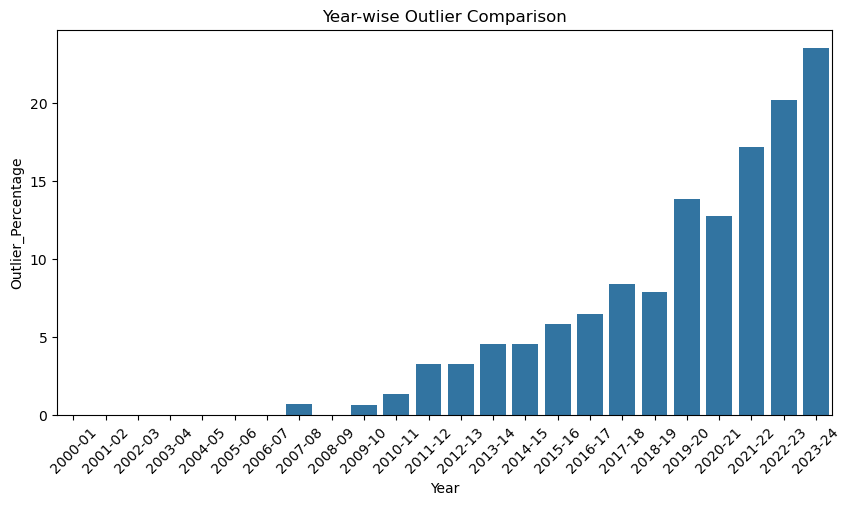

In [14]:
# Bar Plot (Clear Comparison)
plt.figure(figsize=(10,5))

sns.barplot(data=year_summary,
            x='Year', y='Outlier_Percentage')

plt.title("Year-wise Outlier Comparison")
plt.xticks(rotation=45)

plt.show()

In [15]:
# Identify High Shock Years
high_years = year_summary.sort_values(
    by='Outlier_Percentage', ascending=False
).head(5)

print("Years with Highest Outliers:\n")
print(high_years)

Years with Highest Outliers:

       Year  Outlier_Count  Total  Outlier_Percentage
23  2023-24             44    187           23.529412
22  2022-23             38    188           20.212766
21  2021-22             34    198           17.171717
19  2019-20             26    188           13.829787
20  2020-21             26    204           12.745098


In [16]:
year_summary.to_csv("year_wise_outliers.csv", index=False)

In [208]:
outliers_all = df[df['Cost_Outlier'] == True]

print("Total Outlier Rows:", len(outliers_all))
outliers_all.head()

Total Outlier Rows: 1276


,id,year,start_year,end_year,state_name,state_code,crop_name,crop_code,crop_type,cul_cost_a1,...,fix_cost_leased_land_rent,fix_cost_land_rev_tax_cess,fix_cost_depr_impl_farm_build,fix_cost_interest_fix_cap,fix_cost,opr_cost_crop_insurance,Cost_Outlier,Structural_Stress,Environmental_Stress,Policy_Stress
2,2953,2000-01,2000,2001,Punjab,3,Paddy,101,Cereals,9509.84,...,1089.99,0.0,175.08,1007.92,8397.13,NaN,True,False,False,True
3,2954,2000-01,2000,2001,Punjab,3,Wheat,106,Cereals,8474.80,...,1469.91,0.0,217.34,1185.04,10317.99,NaN,True,False,False,True
4,2955,2000-01,2000,2001,Punjab,3,Sunflower,1007,Oilseeds,4515.10,...,3971.23,0.0,117.14,517.68,7318.66,NaN,True,False,False,True
6,2957,2000-01,2000,2001,Punjab,3,Cotton,1101,Fiber Crops,8210.31,...,344.82,0.0,207.46,1073.72,4660.77,NaN,True,False,False,True
10,2961,2000-01,2000,2001,Haryana,6,Gram,201,Pulses,2447.70,...,402.33,0.0,111.62,786.49,3990.20,NaN,True,False,False,True
